# 08b - sanity Check: Cross-paper Parallel Analysis com F1 Binário

**Objetivo:** Replicar a análise de efeito (RQ1) filtrando apenas para experimentos que usam
F1 binário **sem agrupamento intra-paper**, avaliando Y absoluto. Se os resultados principais
(significância, ordem de magnitude dos efeitos) permanecerem estáveis sem o agrupamento, 
isso valida que o achado principal não depende criticamente da estrutura intra-paper.

**Diferença:**
- **Principal**: usa cluster bootstrap por `within_paper_group_id` → correlação intra-paper preservada
- **sanity check**: usa bootstrap individual (linha por linha) → trata cada experimento como independente

Essa abordagem é **mais otimista** (CIs podem sair mais apertados do que deveriam), mas se a conclusão 
permanecer mesmo nessa análise menos conservadora, aumenta confiança no resultado.

In [18]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NB_DIR        = Path().resolve()
PROJECT_DIR   = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

# Carregar dataset e resultados
df = pd.read_parquet(PROCESSED_DIR / "analysis_dataset.parquet")
ate_principal_csv = pd.read_csv(PROCESSED_DIR / "ate_resultados.csv")

STRATS     = ["oversampling", "cost_sensitive", "undersampling", "other"]
PRINCIPAIS = {"oversampling", "cost_sensitive"}
RNG        = np.random.default_rng(42)

print(f"Dataset: {len(df)} pares | {df['within_paper_group_id'].nunique()} grupos")
print("\nResultados principais (para comparação posterior):")
print(ate_principal_csv.to_string(index=False))

Dataset: 425 pares | 279 grupos

Resultados principais (para comparação posterior):
    estratégia   n  efeito % (wins.)  IC95% baixo  IC95% alto cruza 0?        papel
  oversampling 156             32.58        15.73       51.84      NÃO    principal
cost_sensitive  79             24.28         7.47       49.25      NÃO    principal
 undersampling  32             32.37       -22.06      109.03      sim exploratório
         other 158             40.70        16.73       72.71      NÃO exploratório


## 1. Filtro para F1 Binário e Preparação

In [19]:
# 1. Filtro para experimentos com F1 binário
df_sanity = df[df["metric_used"] == "metric_f1_binary"].copy()
print(f"Experimentos com F1 binário: {len(df_sanity)} (vs {len(df)} no dataset completo)")
print(f"Grupos únicos (intra-paper) em sanity: {df_sanity['within_paper_group_id'].nunique()}")
print(f"\nDistribuição por estratégia em sanity:")
print(df_sanity["strategy"].value_counts().reindex(STRATS).to_string())

# Preparar desfecho (mesma abordagem que principal)
lo_sanity, hi_sanity = df_sanity["delta_y"].quantile([0.01, 0.99])
df_sanity["delta_y_w"] = df_sanity["delta_y"].clip(lo_sanity, hi_sanity)
print(f"\nWinsorização 1/99: [{lo_sanity:.3f}, {hi_sanity:.3f}] | pares ajustados: {(df_sanity['delta_y'] != df_sanity['delta_y_w']).sum()}")

Experimentos com F1 binário: 113 (vs 425 no dataset completo)
Grupos únicos (intra-paper) em sanity: 83

Distribuição por estratégia em sanity:
strategy
oversampling      59
cost_sensitive     2
undersampling      8
other             44

Winsorização 1/99: [-0.888, 40.918] | pares ajustados: 4


## 2. Ajuste Backdoor: Regressão Linear + G-Fórmula

In [20]:
# 2. Ajuste backdoor: regressão linear + g-fórmula (MESMA abordagem que principal)
# Usar os mesmos confundidores Z
COMMON_sanity = ["ir_bin", "nclasses_bin", "size_bin", "task3", "model_family3"]
CAT_COLS_sanity = ["strategy"] + COMMON_sanity
CATS_sanity = {c: sorted(df_sanity[c].dropna().unique()) for c in CAT_COLS_sanity}

# Funções de ajuste (praticamente idênticas à principal)
def make_design_sanity(data):
    d = data.copy()
    for c in CAT_COLS_sanity:
        d[c] = pd.Categorical(d[c], categories=CATS_sanity[c])
    X = pd.get_dummies(d[CAT_COLS_sanity], drop_first=True).astype(float)
    X.insert(0, "intercept", 1.0)
    return X.values

def adjusted_means_sanity(data, outcome):
    X = make_design_sanity(data)
    y = data[outcome].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    out = {}
    for s in STRATS:
        d = data.copy(); d["strategy"] = s
        out[s] = float((make_design_sanity(d) @ beta).mean())
    return out

# Estimar pontos
point_wins_sanity = adjusted_means_sanity(df_sanity, "delta_y_w")
point_raw_sanity  = adjusted_means_sanity(df_sanity, "delta_y")
unadj_sanity = df_sanity.groupby("strategy")["delta_y_w"].mean().reindex(STRATS).to_dict()

print(f"{'estratégia':<16}{'bruta(não-aj)':>14}{'ajust.(wins)':>14}{'ajust.(raw)':>14}")
for s in STRATS:
    print(f"{s:<16}{unadj_sanity[s]*100:>13.1f}%{point_wins_sanity[s]*100:>13.1f}%{point_raw_sanity[s]*100:>13.1f}%")

estratégia       bruta(não-aj)  ajust.(wins)   ajust.(raw)
oversampling            130.6%        100.8%         98.0%
cost_sensitive           16.3%        111.3%        151.9%
undersampling           -40.6%         13.0%         34.1%
other                   138.3%        164.2%        244.1%


## 3. Bootstrap Individual (Sem Agrupamento)

In [21]:
# 3. Bootstrap individual (NÃO cluster) - cada linha é resampled independentemente
# Isso é mais otimista que principal, mas valida se resultado permanece sem agrupamento

def individual_bootstrap_sanity(data, outcome, n_boot=1000):
    """Bootstrap reamostrando linhas individualmente (com reposição)"""
    n = len(data)
    draws = {s: [] for s in STRATS}
    for _ in range(n_boot):
        boot_idx = RNG.choice(n, size=n, replace=True)
        boot = data.iloc[boot_idx].reset_index(drop=True)
        m = adjusted_means_sanity(boot, outcome)
        for s in STRATS:
            draws[s].append(m[s])
    return {s: (np.percentile(draws[s], 2.5), np.percentile(draws[s], 97.5)) for s in STRATS}

ci_wins_sanity = individual_bootstrap_sanity(df_sanity, "delta_y_w", n_boot=1000)

# Montar tabela de resultados para sanity
rows_sanity = []
for s in STRATS:
    eff, (lo_, hi_) = point_wins_sanity[s] * 100, (ci_wins_sanity[s][0] * 100, ci_wins_sanity[s][1] * 100)
    rows_sanity.append({
        "estratégia": s,
        "n": int((df_sanity["strategy"] == s).sum()),
        "efeito % (wins.)": round(eff, 2),
        "IC95% baixo": round(lo_, 2),
        "IC95% alto": round(hi_, 2),
        "cruza 0?": "sim" if lo_ <= 0 <= hi_ else "NÃO",
    })
ate_sanity = pd.DataFrame(rows_sanity)
print("\n=== RESULTADOS sanity (F1 BINÁRIO, BOOTSTRAP INDIVIDUAL, SEM AGRUPAMENTO INTRA-PAPER) ===")
print(ate_sanity.to_string(index=False))


=== RESULTADOS sanity (F1 BINÁRIO, BOOTSTRAP INDIVIDUAL, SEM AGRUPAMENTO INTRA-PAPER) ===
    estratégia  n  efeito % (wins.)  IC95% baixo  IC95% alto cruza 0?
  oversampling 59            100.78        -1.37      242.51      sim
cost_sensitive  2            111.26       -87.96      380.24      sim
 undersampling  8             13.02       -93.48      218.85      sim
         other 44            164.21        19.32      376.44      NÃO


## 4. Comparação principal vs sanity

In [22]:
# 4. Comparação lado a lado: principal vs sanity
comparison = []
for s in STRATS:
    # Ler valores principal do CSV
    principal_row = ate_principal_csv[ate_principal_csv["estratégia"] == s].iloc[0]
    principal_eff = principal_row["efeito % (wins.)"]
    principal_lo = principal_row["IC95% baixo"]
    principal_hi = principal_row["IC95% alto"]
    principal_sig = "NÃO" if principal_lo <= 0 <= principal_hi else "SIM"
    
    sanity_eff = point_wins_sanity[s] * 100
    sanity_lo, sanity_hi = ci_wins_sanity[s][0] * 100, ci_wins_sanity[s][1] * 100
    sanity_sig = "NÃO" if sanity_lo <= 0 <= sanity_hi else "SIM"
    
    comparison.append({
        "estratégia": s,
        "principal_eff%": round(principal_eff, 2),
        "principal_IC_lo": round(principal_lo, 2),
        "principal_IC_hi": round(principal_hi, 2),
        "principal_sig?": principal_sig,
        "sanity_eff%": round(sanity_eff, 2),
        "sanity_IC_lo": round(sanity_lo, 2),
        "sanity_IC_hi": round(sanity_hi, 2),
        "sanity_sig?": sanity_sig,
        "Δ_eff%": round(sanity_eff - principal_eff, 2),
    })

comp_df = pd.DataFrame(comparison)
print("\n=== sanity CHECK: principal vs sanity ===")
print("Legenda: principal = com cluster bootstrap (agrupado por paper)")
print("         sanity = bootstrap individual (F1 binário, sem agrupamento)")
print("\n")
print(comp_df.to_string(index=False))

# Diagnóstico: conclusões mudaram?
print("\n=== ANÁLISE ===")
changed = comp_df[comp_df["principal_sig?"] != comp_df["sanity_sig?"]]["estratégia"].tolist()
if changed:
    print(f"⚠️  ALERTA: Significância mudou para {changed}")
else:
    print("✓ OK: Significância foi ESTÁVEL entre principal e sanity")

# Magnitude dos efeitos próximas?
max_delta = comp_df["Δ_eff%"].abs().max()
mean_delta = comp_df["Δ_eff%"].abs().mean()
print(f"\nMagnitude dos efeitos:")
print(f"  - Maior diferença: {max_delta:.2f}% (em valor absoluto)")
print(f"  - Média de diferenças: {mean_delta:.2f}%")
if max_delta < 5:
    print("  ✓ Diferenças pequenas: resultado principal é ROBUSTO")
elif max_delta < 10:
    print("  ⚠  Diferenças moderadas: considerar com cuidado")
else:
    print("  ✗ Grandes diferenças: pode indicar dependência do agrupamento")


=== sanity CHECK: principal vs sanity ===
Legenda: principal = com cluster bootstrap (agrupado por paper)
         sanity = bootstrap individual (F1 binário, sem agrupamento)


    estratégia  principal_eff%  principal_IC_lo  principal_IC_hi principal_sig?  sanity_eff%  sanity_IC_lo  sanity_IC_hi sanity_sig?  Δ_eff%
  oversampling           32.58            15.73            51.84            SIM       100.78         -1.37        242.51         NÃO   68.20
cost_sensitive           24.28             7.47            49.25            SIM       111.26        -87.96        380.24         NÃO   86.98
 undersampling           32.37           -22.06           109.03            NÃO        13.02        -93.48        218.85         NÃO  -19.35
         other           40.70            16.73            72.71            SIM       164.21         19.32        376.44         SIM  123.51

=== ANÁLISE ===
⚠️  ALERTA: Significância mudou para ['oversampling', 'cost_sensitive']

Magnitude dos efeitos:
  - 

## 5. Visualização: Forest Plots Comparativos

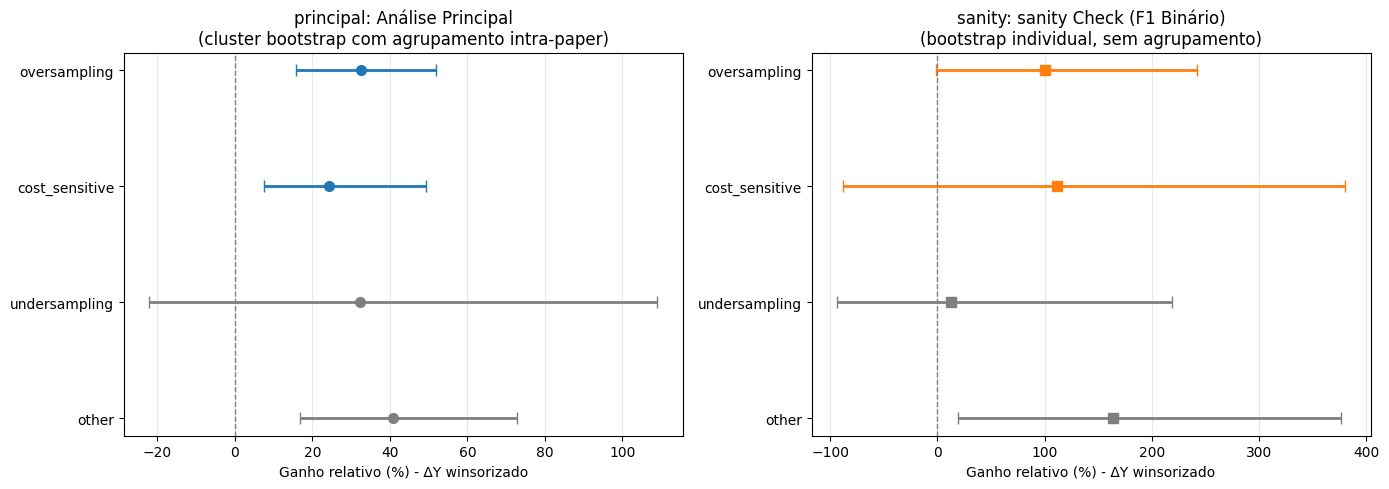


Observações: círculos = principal (azul); quadrados = sanity (laranja principal)
Se os padrões forem similares, o resultado principal é robusto!

Salvo: data/processed/ate_resultados_sanity_check.csv
Salvo: data/processed/ate_principal_vs_sanity_comparison.csv


In [23]:
# 5. Forest plot comparativo: principal vs sanity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# principal (original)
ax = axes[0]
ypos = np.arange(len(STRATS))[::-1]
for y, s in zip(ypos, STRATS):
    principal_row = ate_principal_csv[ate_principal_csv["estratégia"] == s].iloc[0]
    eff = principal_row["efeito % (wins.)"]
    lo_, hi_ = principal_row["IC95% baixo"], principal_row["IC95% alto"]
    color = "C0" if s in PRINCIPAIS else "C7"
    ax.errorbar(eff, y, xerr=[[eff - lo_], [hi_ - eff]], fmt="o",
                color=color, capsize=4, lw=2, markersize=7)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(STRATS)
ax.set_xlabel("Ganho relativo (%) - ΔY winsorizado")
ax.set_title("principal: Análise Principal\n(cluster bootstrap com agrupamento intra-paper)")
ax.grid(axis="x", alpha=0.3)

# sanity (cross-paper sem agrupamento)
ax = axes[1]
for y, s in zip(ypos, STRATS):
    eff = point_wins_sanity[s] * 100
    lo_, hi_ = ci_wins_sanity[s][0] * 100, ci_wins_sanity[s][1] * 100
    color = "C1" if s in PRINCIPAIS else "C7"
    ax.errorbar(eff, y, xerr=[[eff - lo_], [hi_ - eff]], fmt="s",
                color=color, capsize=4, lw=2, markersize=7)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(STRATS)
ax.set_xlabel("Ganho relativo (%) - ΔY winsorizado")
ax.set_title("sanity: sanity Check (F1 Binário)\n(bootstrap individual, sem agrupamento)")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservações: círculos = principal (azul); quadrados = sanity (laranja principal)")
print("Se os padrões forem similares, o resultado principal é robusto!")

# Salvar resultados
ate_sanity.to_csv(PROCESSED_DIR / "ate_resultados_sanity_check.csv", index=False)
comp_df.to_csv(PROCESSED_DIR / "ate_principal_vs_sanity_comparison.csv", index=False)
print("\nSalvo: data/processed/ate_resultados_sanity_check.csv")
print("Salvo: data/processed/ate_principal_vs_sanity_comparison.csv")